In [1]:
import pandas as pd
import numpy as np
from datatools import get_index_K, get_price, get_cyq, get_rzrq, get_moneyflow, get_technical,strategy_metrics
import lightgbm as lgb
import matplotlib.pyplot as plt
from cal_cne6_factor import calc_cne6_factors

### 取特征及样本

In [2]:
allstock = pd.read_csv('data/allstock.csv')
allstock_list = allstock[(allstock['list_date'] < 20260101) & ~allstock['ts_code'].str.contains('BJ') &((allstock['delist_date'] >= 20190101)|(allstock['delist_date'].isna()))].ts_code.tolist()
delist = allstock[(allstock['list_date'] < 20260101) & ~allstock['ts_code'].str.contains('BJ') &(allstock['delist_date'] >= 20190101)].ts_code.tolist()
start_date = '2019-01-01'
end_date = '2026-03-31'

In [3]:
all_sample = get_price(allstock_list, '2019-01-01', '2026-05-31',fields=['open', 'adj_factor'])
all_sample['20d_returns'] = all_sample.groupby('ts_code')['open'].shift(-20) / all_sample['open'] - 1
all_sample.rename(columns={'open':'next_open'}, inplace=True)
all_sample = all_sample.fillna(-0.9999999)
all_sample['trade_date'] = all_sample.groupby('ts_code')['trade_date'].shift(1)
all_sample = all_sample[all_sample.trade_date.between(start_date, end_date)]

In [6]:
bench = get_index_K(['000852.SH'], start_date='2019-01-01', end_date='2026-05-31', fields=['open'])
bench['bench_20d_return'] = bench['open'].shift(-20) / bench['open'] -1
bench['trade_date'] = bench['trade_date'].shift(1)

all_sample = all_sample.merge(bench[['trade_date', 'bench_20d_return']], on='trade_date', how='left')
all_sample['20d_excess_returns'] = all_sample['20d_returns'] - all_sample['bench_20d_return']
all_sample['Y_20d'] = all_sample.groupby('trade_date')['20d_excess_returns'].rank(pct=True)

In [9]:
all_sample.to_parquet('data/factor/all_sample.parquet', index=False)

In [20]:
factor1_de = calc_cne6_factors(delist, '2019-01-01', '2026-03-31')

cyq = get_cyq(delist, '2019-01-01', '2026-03-31')
rzrq = get_rzrq(delist, '2019-01-01', '2026-03-31')
monthflow = get_moneyflow(delist, '2019-01-01', '2026-03-31')

tech = get_technical(delist, '2019-01-01', '2026-03-31')

加载价格数据...
加载指数数据...
矩阵: 2019 交易日 × 221 只股票
计算 Daily std...
计算 Cumulative range...


c:\Users\User\Desktop\Quant\cal_cne6_factor.py:99: RuntimeWarning: All-NaN slice encountered
  factor_values = np.nanmax(window_rets, axis=0) - np.nanmin(window_rets, axis=0)


计算 Short Term reversal...
计算 Seasonality...
计算 Industry Momentum...
计算 BETA / Hist sigma / Historical alpha...
计算 Relative strength...
加载长期价格数据...
加载长期指数数据...
计算 Long term relative strength...
计算 Long term historical alpha...
加载基础数据...
加载财务数据...
加载TTM数据...
计算换手率因子...
计算市值因子...
计算估值/杠杆因子...
计算盈利能力...
计算财务质量因子...
计算应计项目...
计算投资质量...
加载分析师预测数据...
计算分析师预测因子...
组装结果...
done


In [ ]:
factor1_de = factor1_de[~factor1_de['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor1 = pd.concat([factor1, factor1_de]).sort_values(['trade_date','ts_code'])
factor1.to_parquet('data/factor/cne6_factor.parquet', index=False)

In [ ]:
factor2_de = pd.merge(cyq, rzrq, on=['trade_date', 'ts_code'], how='outer').merge(monthflow, on=['trade_date', 'ts_code'], how='outer')
factor2_de = factor2_de[~factor2_de['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor2 = pd.concat([factor2, factor2_de]).sort_values(['trade_date','ts_code'])
factor2.to_parquet('data/factor/other_factor.parquet', index=False)

In [ ]:
tech = tech[~tech['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor3 = pd.concat([factor3, tech]).sort_values(['trade_date','ts_code'])
factor3.to_parquet('data/factor/tech_factor.parquet', index=False)

### 读取样本

In [ ]:
all_sample = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/all_sample.parquet')
factor1 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/cne6_factor.parquet')
factor2 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/other_factor.parquet')
factor3 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/tech_factor.parquet')

In [ ]:
sample = all_sample.query( 'trade_date >= "2023-01-01"') ## oot
#sample = all_sample.query( 'trade_date < "2023-01-01"') # train
factor = sample.merge(factor1, on=['ts_code', 'trade_date'], how='left').merge(
    factor2, on=['ts_code', 'trade_date'], how='left').merge(factor3, on=['ts_code', 'trade_date'], how='left')

In [ ]:
ind = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/industry.csv')
factor = factor.merge(ind[['ts_code', 'l1_name']], on='ts_code', how='left')
factor = pd.get_dummies(factor, columns=['l1_name'], drop_first=True, dtype=int)

def neutralize_date(group):
    X_raw = group[factor.columns[-30:].tolist() + ['lncap']].values
    X = np.column_stack((np.ones(X_raw.shape[0]), X_raw))
    # 预分配残差矩阵，默认全为 NaN
    resid_matrix = np.full((group.shape[0], 155), np.nan)
    # 2. 必须按列独立回归，处理各自的缺失值
    for j, col in enumerate(factor.columns[8:-30]):
        try:
            median = group[col].median()
            mad = (group[col] - median).abs().median()
            group[col] = group[col].clip(median - 5 * mad, median + 5 * mad)
            mean = group[col].mean()
            std = group[col].std()
            if std == 0:
                group[col] = np.nan  # 波动为0的因子无信息，置0
            else:
                group[col] = (group[col] - mean) / std
            
            Y_raw = group[col].values
            # 核心：只判断当前因子列的缺失值
            valid_idx = ~np.isnan(Y_raw) & np.all(~np.isnan(X), axis=1)
            X_valid = X[valid_idx]
            Y_valid = Y_raw[valid_idx]
            # 3. 底层 NumPy 最小二乘法求解
            beta, _, _, _ = np.linalg.lstsq(X_valid, Y_valid[:, np.newaxis])
            # 计算残差并展平为一维
            resid_valid = Y_valid - (X_valid @ beta).flatten()
            # 4. 只将有效行的残差填入对应位置，无效行保持 NaN
            resid_matrix[valid_idx, j] = resid_valid
        except:
            print(group.name, col)
    # 5. 映射回 DataFrame
    group[factor.columns[8:-30]] = resid_matrix
    return group
factor =  factor.groupby('trade_date').apply(neutralize_date).reset_index(level=0)
factor = factor.drop(columns=factor.columns[-30:].tolist() + ['lncap'])

In [ ]:
factor.to_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_oot.parquet', index=False)

#### training

In [ ]:
sample_train = all_sample.query( 'trade_date < "2023-01-01"').merge(factor1, on=['ts_code', 'trade_date'], how='left').merge(
    factor2, on=['ts_code', 'trade_date'], how='left').merge(factor3, on=['ts_code', 'trade_date'], how='left')

sample_oot = all_sample.query( 'trade_date >= "2023-01-01"').merge(factor1, on=['ts_code', 'trade_date'], how='left').merge(
    factor2, on=['ts_code', 'trade_date'], how='left').merge(factor3, on=['ts_code', 'trade_date'], how='left')
sample_oot['daily_return'] = sample_oot.groupby('ts_code')['next_open'].pct_change().fillna(0)

In [2]:
sample_train = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_train.parquet')
sample_oot = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_oot.parquet')
sample_oot['daily_return'] = sample_oot.groupby('ts_code')['next_open'].pct_change().fillna(0)

In [3]:
index_weight = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/index/index_weight/index_weight-000300.SH.parquet')
index_weight.trade_date = pd.to_datetime(index_weight.trade_date)
index_weight = index_weight[index_weight.trade_date.between('2019-01-01', '2026-03-31')].rename(columns={'con_code':'ts_code'})

In [ ]:
index_weight['year_month'] = index_weight['trade_date'].dt.to_period('M')
monthly_stocks = index_weight.groupby('year_month')['ts_code'].apply(set).reset_index()
monthly_stocks['prev_stocks'] = monthly_stocks['ts_code'].shift(1)
# 3. 定义函数计算差异（新增数、剔除数、总变动数）
def calc_changes(row):
    if pd.isna(row['prev_stocks']):
        return pd.Series({'新增数量': 0, '剔除数量': 0, '总变动数量': 0})
    curr_stocks = row['ts_code']
    prev_stocks = row['prev_stocks']
    # 本月有但上月没有的（新增/调入）
    added = len(curr_stocks - prev_stocks)
    # 上月有但本月没有的（剔除/调出）
    removed = len(prev_stocks - curr_stocks)
    # 总变动数量 = 新增 + 剔除
    total_changed = added + removed
    return pd.Series({'新增数量': added, '剔除数量': removed, '总变动数量': total_changed})
# 4. 应用计算并输出结果
changes = monthly_stocks.apply(calc_changes, axis=1)
result = pd.concat([monthly_stocks[['year_month']], changes], axis=1)

   year_month  新增数量  剔除数量  总变动数量
0     2019-01     0     0      0
1     2019-02     0     0      0
2     2019-03     0     0      0
3     2019-04     0     0      0
4     2019-05     0     0      0
..        ...   ...   ...    ...
82    2025-11     0     0      0
83    2025-12    11     0     11
84    2026-01     0    11     11
85    2026-02     0     0      0
86    2026-03     0     0      0

[87 rows x 4 columns]


In [5]:
result

,year_month,新增数量,剔除数量,总变动数量
0,2019-01,0,0,0
1,2019-02,0,0,0
2,2019-03,0,0,0
3,2019-04,0,0,0
4,2019-05,0,0,0
...,...,...,...,...
82,2025-11,0,0,0
83,2025-12,11,0,11
84,2026-01,0,11,11
85,2026-02,0,0,0


In [ ]:
merged_df = pd.merge_asof(sample_train, index_weight, on='trade_date', by='ts_code',  direction='backward')

In [ ]:
index_weight = index_weight[index_weight['trade_date'].dt.month.isin([6, 12])]

Index(['index_code', 'ts_code', 'trade_date', 'weight'], dtype='str')

In [35]:
# 从 train_val_df 中切出 20% 作为验证集 (按时间切，比如22年全年)
val_df = sample_train[sample_train['trade_date'] >= '2022-05-01']
train_df = sample_train[sample_train['trade_date'] < '2022-05-01']
feature_cols = sample_train.columns[8:]
lgb_train = lgb.Dataset(train_df[feature_cols], train_df['Y_20d'])
lgb_val = lgb.Dataset(val_df[feature_cols], val_df['Y_20d'])

In [36]:

lgb_params = {
    'objective': 'regression', 
    'metric': 'rmse', 
    'learning_rate': 0.03,     
    'max_depth': 4,            
    'num_leaves': 10,          
    'subsample': 0.7,          
    'colsample_bytree': 0.6,   
    'reg_alpha': 0.5,          
    'reg_lambda': 1.0,         
    'min_child_samples': 200,  
    'n_estimators': 1000,      
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 3. 训练模型
model = lgb.train(
    lgb_params,
    lgb_train,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(10)]
    )
# 在 OOT 集(23年+)上进行日频预测 对预测结果做截面标准化
sample_oot['predict_score'] = model.predict(sample_oot[feature_cols])
#daily_ic = sample_oot.groupby('trade_date').apply(lambda x: x['predict_score'].corr(x['Y_20d'], method='spearman'))

Training until validation scores don't improve for 10 rounds
[10]	valid_0's rmse: 0.283725
[20]	valid_0's rmse: 0.282784
[30]	valid_0's rmse: 0.282188
[40]	valid_0's rmse: 0.281802
[50]	valid_0's rmse: 0.281496
[60]	valid_0's rmse: 0.28123
[70]	valid_0's rmse: 0.281057
[80]	valid_0's rmse: 0.280933
[90]	valid_0's rmse: 0.280814
[100]	valid_0's rmse: 0.280734
[110]	valid_0's rmse: 0.280687
[120]	valid_0's rmse: 0.28064
[130]	valid_0's rmse: 0.280625
[140]	valid_0's rmse: 0.280575
[150]	valid_0's rmse: 0.280542
[160]	valid_0's rmse: 0.280498
[170]	valid_0's rmse: 0.280483
[180]	valid_0's rmse: 0.28046
Early stopping, best iteration is:
[178]	valid_0's rmse: 0.280455


In [37]:
feat_imp_df = pd.DataFrame({'feature': model.feature_name(), 'gain': model.feature_importance(importance_type='gain')})
feat_imp_df['gain'] /= feat_imp_df['gain'].sum()
feat_imp_df = feat_imp_df.sort_values(by='gain', ascending=False)
print("Top 10 Features by Gain:")
print(feat_imp_df.head(10))

Top 10 Features by Gain:
           feature      gain
0        daily_std  0.171686
6       hist_sigma  0.062010
54     winner_rate  0.044211
42            adtp  0.041732
13            stom  0.040762
62  sell_md_amount  0.037173
81         asi_hfq  0.030030
45       delta_cnt  0.028755
48       cost_5pct  0.026335
3           season  0.024151


### step 4

In [ ]:
# sample_oot : DataFrame, 包含 'trade_date', 'ts_code','daily_return' 列
# trade_records : DataFrame, 交易记录, 包含 'ts_code', 'buy_date', 'buy_price', 'sell_date', 'sell_price' 列

In [57]:
sample_oot['sell_price'] = sample_oot.groupby('ts_code')['next_open'].shift(-20)
sample_oot['sell_date'] = sample_oot.groupby('ts_code')['trade_date'].shift(-20)

unique_dates = sample_oot['trade_date'].drop_duplicates().sort_values().reset_index(drop=True)
signal_dates = set(unique_dates[(unique_dates.index) % 20 == 0])
signal_df = sample_oot[sample_oot['trade_date'].isin(signal_dates)]
trade_records = signal_df[signal_df.groupby('trade_date')['predict_score'].rank(method='first', pct=True) > 0.9]
trade_records = trade_records[['ts_code', 'trade_date', 'next_open', 'sell_date', 'sell_price']].rename(columns={'trade_date': 'buy_date', 'next_open': 'buy_price'})
trade_records = trade_records[trade_records.sell_date.notna()]
trade_records['return'] = trade_records['sell_price'] / trade_records['buy_price'] - 1

In [68]:
metrics, df_res = strategy_metrics(sample_oot[['trade_date', 'ts_code', 'daily_return']], trade_records, '000852.SH')

In [67]:
trade_records[trade_records['buy_date']=='2024-01-26'].sort_values('return')

,ts_code,buy_date,buy_price,sell_date,sell_price,return,trade_days
1302392,002822.SZ,2024-01-26,8.68186,2024-03-05,5.15096,-0.406699,26.000000
1302351,002775.SZ,2024-01-26,18.40046,2024-03-04,11.90618,-0.352941,25.333333
1304056,600165.SH,2024-01-26,14.91600,2024-03-04,10.29204,-0.310000,25.333333
1304565,600802.SH,2024-01-26,17.71230,2024-03-04,12.36388,-0.301961,25.333333
1301853,002247.SZ,2024-01-26,14.20653,2024-03-04,9.92511,-0.301370,25.333333
...,...,...,...,...,...,...,...
1302299,002716.SZ,2024-01-26,9.88344,2024-03-04,11.29536,0.142857,25.333333
1301624,002009.SZ,2024-01-26,60.65104,2024-03-04,69.44652,0.145018,25.333333
1302019,002418.SZ,2024-01-26,13.04217,2024-03-04,15.04097,0.153257,25.333333
1302244,002656.SZ,2024-01-26,8.00149,2024-03-04,9.27325,0.158940,25.333333


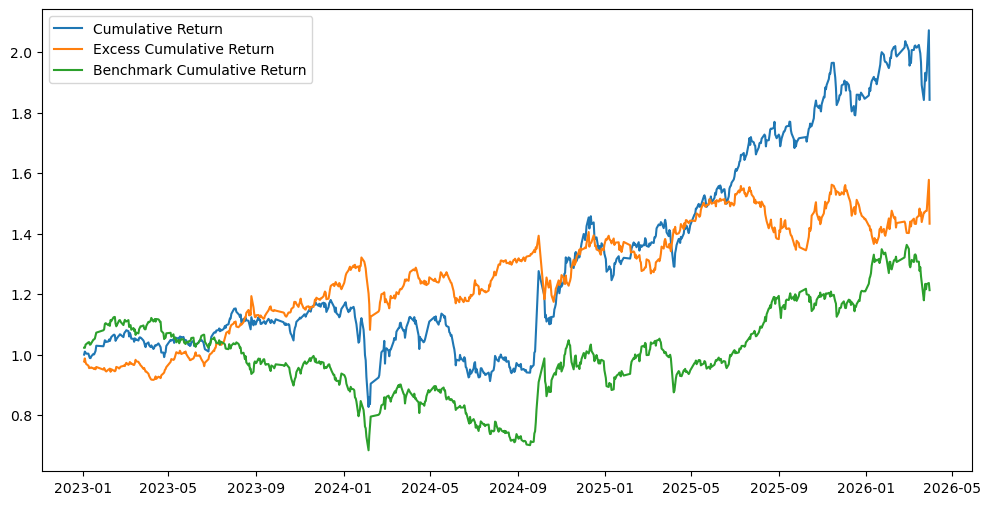

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(df_res['trade_date'], df_res['cum_nav'], label='Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_excess_nav'], label='Excess Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_bench_nav'], label='Benchmark Cumulative Return')
plt.legend()
plt.show()